In [1]:
import pandas as pd
df = pd.read_csv('zameen-updated.csv\zameen-updated.csv')

In [2]:
df.head()

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent,Area Type,Area Size,Area Category
0,237062,3325,https://www.zameen.com/Property/g_10_g_10_2_gr...,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,4 Marla,For Sale,2,02-04-2019,NaN,NaN,Marla,4.0,0-5 Marla
1,346905,3236,https://www.zameen.com/Property/e_11_2_service...,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,5.6 Marla,For Sale,3,05-04-2019,NaN,NaN,Marla,5.6,5-10 Marla
2,386513,764,https://www.zameen.com/Property/islamabad_g_15...,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,8 Marla,For Sale,5,07-17-2019,NaN,NaN,Marla,8.0,5-10 Marla
3,656161,340,https://www.zameen.com/Property/islamabad_bani...,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,2 Kanal,For Sale,4,04-05-2019,NaN,NaN,Kanal,2.0,1-5 Kanal
4,841645,3226,https://www.zameen.com/Property/dha_valley_dha...,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,8 Marla,For Sale,3,07-10-2019,Easy Property,Muhammad Junaid Ceo Muhammad Shahid Director,Marla,8.0,5-10 Marla


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168446 entries, 0 to 168445
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   property_id    168446 non-null  int64  
 1   location_id    168446 non-null  int64  
 2   page_url       168446 non-null  object 
 3   property_type  168446 non-null  object 
 4   price          168446 non-null  int64  
 5   location       168446 non-null  object 
 6   city           168446 non-null  object 
 7   province_name  168446 non-null  object 
 8   latitude       168446 non-null  float64
 9   longitude      168446 non-null  float64
 10  baths          168446 non-null  int64  
 11  area           168446 non-null  object 
 12  purpose        168446 non-null  object 
 13  bedrooms       168446 non-null  int64  
 14  date_added     168446 non-null  object 
 15  agency         124375 non-null  object 
 16  agent          124374 non-null  object 
 17  Area Type      168446 non-nul

In [4]:
df1 = df.copy()

In [5]:
columns_to_drop = ['property_id', 'location_id', 'page_url', 'area']
df1.drop(columns=columns_to_drop, inplace=True)

# Verify they're gone
print(df1.columns.tolist())

['property_type', 'price', 'location', 'city', 'province_name', 'latitude', 'longitude', 'baths', 'purpose', 'bedrooms', 'date_added', 'agency', 'agent', 'Area Type', 'Area Size', 'Area Category']


In [6]:
# Fill missing agency and agent with "Unknown"
df['agency'].fillna('Unknown', inplace=True)
df['agent'].fillna('Unknown', inplace=True)

# Verify
print(df[['agency', 'agent']].isnull().sum())

agency    0
agent     0
dtype: int64


/tmp/ipykernel_55/2227575167.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['agency'].fillna('Unknown', inplace=True)
/tmp/ipykernel_55/2227575167.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

Based on Pakistani real estate, common units are:

Marla (1 Marla = 272.25 sq ft)

Kanal (1 Kanal = 5445 sq ft, which is 20 Marlas)

Square Feet (already in sq ft)

Square Yard (1 sq yd = 9 sq ft)

Possibly others like Acre (1 acre = 43560 sq ft) if present.

In [7]:
print(df1['Area Type'].value_counts())

Area Type
Marla    137769
Kanal     30677
Name: count, dtype: int64


In [8]:
conversion = {
    'Marla': 272.25,
    'Kanal': 5445,
}

In [9]:
# Create new column 'area_sqft' by multiplying Area Size by conversion factor
df1['area_sqft'] = df1.apply(
    lambda row: row['Area Size'] * conversion.get(row['Area Type'], 1), 
    axis=1
)

# Verify a few rows
print(df1[['Area Type', 'Area Size', 'area_sqft']].head(10))

  Area Type  Area Size  area_sqft
0     Marla        4.0    1089.00
1     Marla        5.6    1524.60
2     Marla        8.0    2178.00
3     Kanal        2.0   10890.00
4     Marla        8.0    2178.00
5     Kanal        1.6    8712.00
6     Kanal        1.0    5445.00
7     Marla        6.2    1687.95
8     Kanal        1.0    5445.00
9     Kanal        1.0    5445.00


In [10]:
df1

,property_type,price,location,city,province_name,latitude,longitude,baths,purpose,bedrooms,date_added,agency,agent,Area Type,Area Size,Area Category,area_sqft
0,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,For Sale,2,02-04-2019,NaN,NaN,Marla,4.0,0-5 Marla,1089.00
1,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,For Sale,3,05-04-2019,NaN,NaN,Marla,5.6,5-10 Marla,1524.60
2,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,For Sale,5,07-17-2019,NaN,NaN,Marla,8.0,5-10 Marla,2178.00
3,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,For Sale,4,04-05-2019,NaN,NaN,Kanal,2.0,1-5 Kanal,10890.00
4,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,For Sale,3,07-10-2019,Easy Property,Muhammad Junaid Ceo Muhammad Shahid Director,Marla,8.0,5-10 Marla,2178.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168441,House,26500000,Gadap Town,Karachi,Sindh,25.029909,67.137192,0,For Sale,6,07-18-2019,Al Shahab Enterprises,Shahmir,Marla,9.6,5-10 Marla,2613.60
168442,House,12500000,Gadap Town,Karachi,Sindh,25.017951,67.136393,0,For Sale,3,07-18-2019,Al Shahab Enterprises,Shahmir,Marla,8.0,5-10 Marla,2178.00
168443,House,27000000,Gadap Town,Karachi,Sindh,25.015384,67.116330,0,For Sale,6,07-18-2019,Al Shahab Enterprises,Shahmir,Marla,9.6,5-10 Marla,2613.60
168444,House,11000000,Gadap Town,Karachi,Sindh,25.013265,67.120818,0,For Sale,3,07-18-2019,Al Shahab Enterprises,Shahmir,Marla,7.8,5-10 Marla,2123.55


In [11]:
# Convert to datetime
df1['date_added'] = pd.to_datetime(df1['date_added'], format='%m-%d-%Y')

# Extract features
df1['year'] = df1['date_added'].dt.year
df1['month'] = df1['date_added'].dt.month
df1['day_of_week'] = df1['date_added'].dt.dayofweek

# Optionally drop original date column
df1.drop('date_added', axis=1, inplace=True)

In [12]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168446 entries, 0 to 168445
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   property_id    168446 non-null  int64  
 1   location_id    168446 non-null  int64  
 2   page_url       168446 non-null  object 
 3   property_type  168446 non-null  object 
 4   price          168446 non-null  int64  
 5   location       168446 non-null  object 
 6   city           168446 non-null  object 
 7   province_name  168446 non-null  object 
 8   latitude       168446 non-null  float64
 9   longitude      168446 non-null  float64
 10  baths          168446 non-null  int64  
 11  area           168446 non-null  object 
 12  purpose        168446 non-null  object 
 13  bedrooms       168446 non-null  int64  
 14  date_added     168446 non-null  object 
 15  agency         168446 non-null  object 
 16  agent          168446 non-null  object 
 17  Area Type      168446 non-nul

,property_id,location_id,price,latitude,longitude,baths,bedrooms,Area Size
count,1.684460e+05,168446.000000,1.684460e+05,168446.000000,168446.000000,168446.000000,168446.000000,168446.000000
mean,1.559626e+07,4375.936395,1.776576e+07,29.859519,71.239804,2.874227,3.179422,5.892188
std,2.251207e+06,3776.561581,3.531003e+07,3.807870,3.133042,2.463400,1.971401,5.778327
min,8.657500e+04,1.000000,0.000000e+00,11.052446,25.906027,0.000000,0.000000,0.000000
25%,1.488320e+07,1058.000000,1.750000e+05,24.948536,67.130363,0.000000,2.000000,3.000000
50%,1.665851e+07,3286.000000,8.500000e+06,31.459784,73.056182,3.000000,3.000000,5.000000
75%,1.708662e+07,7220.000000,1.950000e+07,33.560887,73.259870,4.000000,4.000000,8.000000
max,1.735772e+07,14220.000000,2.000000e+09,73.184088,80.161430,403.000000,68.000000,800.000000


Area Category → optional. It’s a binned version of area (e.g., "0-5 Marla"). You can keep it as a categorical feature if it might help the model, or drop it if you prefer a single numeric area. I suggest keeping it for now and later checking feature importance.

In [13]:
df1.drop(['Area Type', 'Area Size'], axis=1, inplace=True)


In [14]:
# 1. Check for zero or negative values
numeric_cols = ['price', 'baths', 'bedrooms', 'area_sqft']
for col in numeric_cols:
    invalid = df1[df1[col] <= 0]
    if not invalid.empty:
        print(f"{col}: {len(invalid)} rows with <= 0")
        print(invalid[[col]].head())
    else:
        print(f"{col}: all positive")

# 2. Check for extreme outliers (optional, but good to know)
# Use percentiles to see the range
print(df1[numeric_cols].describe(percentiles=[0.01, 0.99]))

price: 3 rows with <= 0
        price
66537       0
91608       0
132855      0
baths: 42382 rows with <= 0
    baths
12      0
19      0
47      0
49      0
54      0
bedrooms: 22704 rows with <= 0
    bedrooms
12         0
19         0
47         0
60         0
83         0
area_sqft: 12 rows with <= 0
        area_sqft
29631         0.0
38288         0.0
115388        0.0
128223        0.0
130493        0.0
              price          baths       bedrooms     area_sqft
count  1.684460e+05  168446.000000  168446.000000  1.684460e+05
mean   1.776576e+07       2.874227       3.179422  3.252030e+03
std    3.531003e+07       2.463400       1.971401  2.460602e+04
min    0.000000e+00       0.000000       0.000000  0.000000e+00
1%     1.500000e+04       0.000000       0.000000  4.900500e+02
50%    8.500000e+06       3.000000       3.000000  1.932975e+03
99%    1.600000e+08       8.000000       9.000000  1.361250e+04
max    2.000000e+09     403.000000      68.000000  4.356000e+06


The output shows that there are rows with zero or negative values in key numeric columns. This is common in real estate datasets—often zeros indicate missing data, "price on call" listings, or data entry errors. Since we have a large dataset (168k rows), filtering out these invalid rows is a reasonable approach.

1. Remove Invalid Rows
We'll filter df1 to keep only rows where:

price > 0

baths > 0

bedrooms > 0

area_sqft > 0

In [15]:
# Filter out invalid rows
df_clean = df1[
    (df1['price'] > 0) &
    (df1['baths'] > 0) &
    (df1['bedrooms'] > 0) &
    (df1['area_sqft'] > 0)
].copy()

print(f"Original rows: {len(df1)}")
print(f"Rows after cleaning: {len(df_clean)}")
print(f"Rows removed: {len(df1) - len(df_clean)}")

Original rows: 168446
Rows after cleaning: 125613
Rows removed: 42833


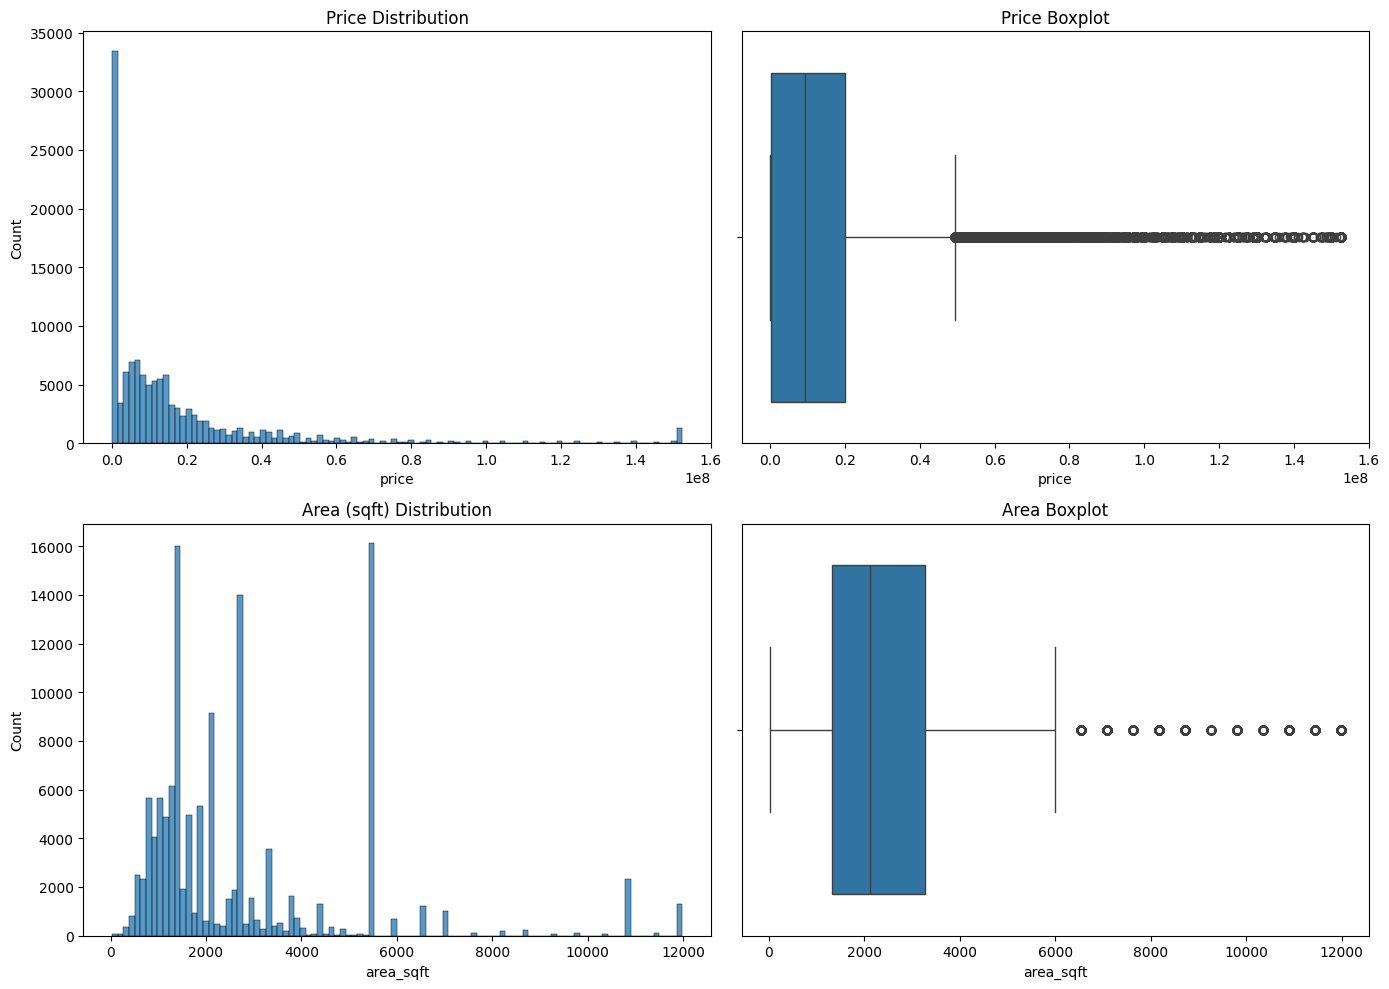

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_clean['price'], bins=100, ax=axes[0,0])
axes[0,0].set_title('Price Distribution')
sns.boxplot(x=df_clean['price'], ax=axes[0,1])
axes[0,1].set_title('Price Boxplot')

sns.histplot(df_clean['area_sqft'], bins=100, ax=axes[1,0])
axes[1,0].set_title('Area (sqft) Distribution')
sns.boxplot(x=df_clean['area_sqft'], ax=axes[1,1])
axes[1,1].set_title('Area Boxplot')

plt.tight_layout()
plt.show()

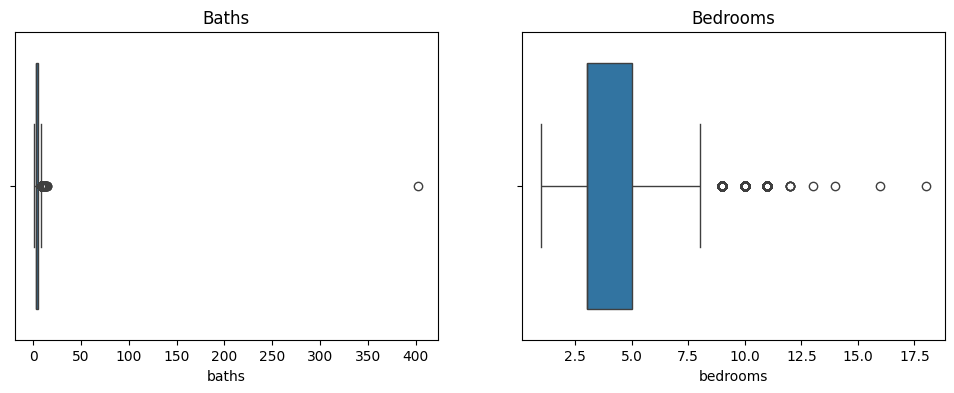

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df_clean['baths'], ax=axes[0])
axes[0].set_title('Baths')
sns.boxplot(x=df_clean['bedrooms'], ax=axes[1])
axes[1].set_title('Bedrooms')
plt.show()

In [18]:
# Calculate 99th percentiles
price_99 = df_clean['price'].quantile(0.99)
area_99 = df_clean['area_sqft'].quantile(0.99)

print(f"99th percentile price: {price_99:,.0f}")
print(f"99th percentile area: {area_99:,.0f}")

# Cap values
df_clean['price_capped'] = df_clean['price'].clip(upper=price_99)
df_clean['area_sqft_capped'] = df_clean['area_sqft'].clip(upper=area_99)

# Or you can replace the original columns if you prefer
df_clean['price'] = df_clean['price'].clip(upper=price_99)
df_clean['area_sqft'] = df_clean['area_sqft'].clip(upper=area_99)

99th percentile price: 152,440,000
99th percentile area: 11,979


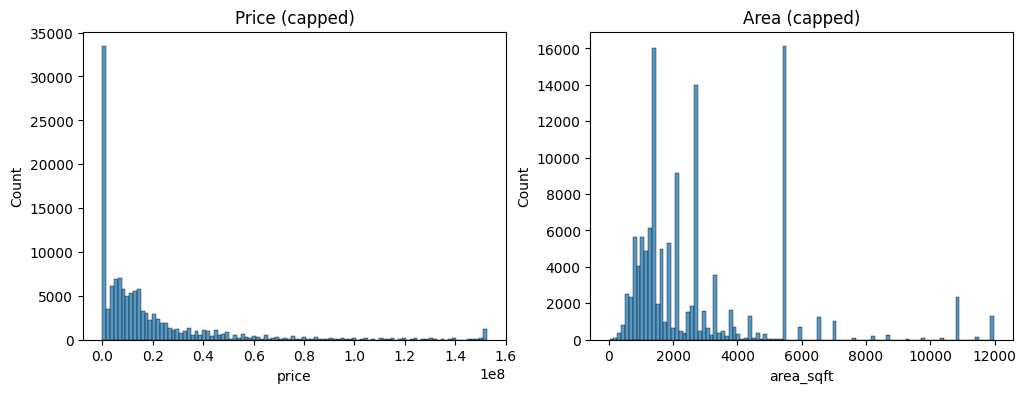

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_clean['price'], bins=100, ax=axes[0])
axes[0].set_title('Price (capped)')
sns.histplot(df_clean['area_sqft'], bins=100, ax=axes[1])
axes[1].set_title('Area (capped)')
plt.show()

## Step 1 - Project Scope and Success Metrics
Professional objective: predict **housing sale prices** (PKR) from listing features.

Rules for this project:
- Use sale listings only (`purpose == 'For Sale'`)
- Build one canonical modeling dataframe (`model_df`)
- Evaluate with RMSE and MAE as primary metrics; R2 and MAPE as secondary

In [3]:
import numpy as np
import pandas as pd

# Build from the latest cleaned frame if available, otherwise fallback safely
if 'df_clean' in globals():
    base_df = df_clean.copy()
elif 'df1' in globals():
    base_df = df1.copy()
else:
    base_df = df.copy()

# Ensure key text fields are consistently filled
for col in ['agency', 'agent']:
    if col in base_df.columns:
        base_df[col] = base_df[col].fillna('Unknown')

# Project scope: sale listings only (case-insensitive safety)
if 'purpose' in base_df.columns:
    sale_mask = base_df['purpose'].astype(str).str.strip().str.lower().eq('for sale')
    model_df = base_df.loc[sale_mask].copy()
else:
    model_df = base_df.copy()

# Keep only valid target/area rows
if 'price' in model_df.columns:
    model_df = model_df[model_df['price'] > 0].copy()
if 'area_sqft' in model_df.columns:
    model_df = model_df[model_df['area_sqft'] > 0].copy()

# Remove helper duplicates if present
model_df = model_df.drop(columns=['price_capped', 'area_sqft_capped'], errors='ignore')

# Define target and features
y = np.log1p(model_df['price'])
X = model_df.drop(columns=['price'])

# Success metrics for this project
project_metrics = {
    'primary': ['RMSE', 'MAE'],
    'secondary': ['R2', 'MAPE'],
}

print('Model scope established')
print('Rows in model_df:', len(model_df))
print('X shape:', X.shape)
print('y shape:', y.shape)
print('Purpose distribution in model_df:')
print(model_df['purpose'].value_counts(dropna=False) if 'purpose' in model_df.columns else 'purpose column not available')
print('Metrics:', project_metrics)

Model scope established
Rows in model_df: 120653
X shape: (120653, 19)
y shape: (120653,)
Purpose distribution in model_df:
purpose
For Sale    120653
Name: count, dtype: int64
Metrics: {'primary': ['RMSE', 'MAE'], 'secondary': ['R2', 'MAPE']}


In [5]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# 80/20 split, then split 20% temp into 10% val + 10% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

numeric_features = X_train.select_dtypes(exclude=['object']).columns.tolist()
all_categorical = X_train.select_dtypes(include=['object']).columns.tolist()

# Memory-safe policy: drop extreme-cardinality categorical columns for OHE
max_unique_for_ohe = 100
categorical_features = []
dropped_high_cardinality = []
for c in all_categorical:
    nunique = X_train[c].nunique(dropna=True)
    if nunique <= max_unique_for_ohe:
        categorical_features.append(c)
    else:
        dropped_high_cardinality.append((c, nunique))

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True, dtype=np.float32)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='drop',
    sparse_threshold=1.0
)

# Fit only on training data to avoid leakage
preprocessor.fit(X_train)
X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print('Split complete')
print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)
print('Numeric features:', len(numeric_features))
print('Categorical features used for OHE:', len(categorical_features))
print('Dropped high-cardinality categorical columns:', dropped_high_cardinality)
print('Processed shapes -> Train:', X_train_processed.shape, 'Val:', X_val_processed.shape, 'Test:', X_test_processed.shape)

Split complete
Train: (96522, 19) Val: (12065, 19) Test: (12066, 19)
Numeric features: 7
Categorical features used for OHE: 6
Dropped high-cardinality categorical columns: [('page_url', 96522), ('location', 1404), ('area', 318), ('date_added', 118), ('agency', 5294), ('agent', 8963)]
Processed shapes -> Train: (96522, 45) Val: (12065, 45) Test: (12066, 45)


## Step 2 - Data Split and Preprocessing Pipeline
Create train, validation, and test sets with reproducible random seeds, then build a leakage-safe preprocessing pipeline.

Pipeline design:
- Numeric columns: median imputation + scaling
- Categorical columns: most-frequent imputation + one-hot encoding with unknown handling

In [7]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

def evaluate_on_original_scale(y_true_log, y_pred_log, model_name):
    y_true_log = np.asarray(y_true_log, dtype=np.float64)
    y_pred_log = np.asarray(y_pred_log, dtype=np.float64)

    # Keep inverse transform numerically stable and realistic
    y_pred_log = np.clip(y_pred_log, y_train.min(), y_train.max())

    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    return {
        'model': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'MAPE': mape,
    }

results = []

# Baseline 1: median predictor in log-space
median_log_price = float(np.median(y_train))
y_val_pred_median_log = np.full(shape=len(y_val), fill_value=median_log_price)
results.append(evaluate_on_original_scale(y_val.values, y_val_pred_median_log, 'Median Baseline'))

# Baseline 2: Ridge regression on processed features (sparse-safe solver)
ridge_model = Ridge(alpha=1.0, solver='lsqr', random_state=42)
ridge_model.fit(X_train_processed, y_train)
y_val_pred_ridge_log = ridge_model.predict(X_val_processed)
results.append(evaluate_on_original_scale(y_val.values, y_val_pred_ridge_log, 'Ridge Baseline'))

results_df = pd.DataFrame(results).sort_values(by='RMSE', ascending=True).reset_index(drop=True)
results_df[['RMSE', 'MAE', 'MAPE']] = results_df[['RMSE', 'MAE', 'MAPE']].round(3)
results_df['R2'] = results_df['R2'].round(5)

print('Validation performance (original PKR scale):')
display(results_df)

Validation performance (original PKR scale):


,model,RMSE,MAE,R2,MAPE
0,Ridge Baseline,3.368676e+07,1.004085e+07,0.26767,0.702
1,Median Baseline,4.092636e+07,1.712558e+07,-0.08093,1.119


## Step 3 - Baseline Modeling and Validation Metrics
Train professional baselines and evaluate on validation set using RMSE, MAE, R2, and MAPE in original PKR scale.

Baselines in this step:
- Median baseline (naive reference)
- Ridge regression (regularized linear baseline)

## Step 4 - Tree Model with Hyperparameter Tuning
Tune a Random Forest model using cross-validated randomized search, then evaluate on the same validation split for fair comparison.

In [8]:
import numpy as np
import pandas as pd
from scipy.sparse import issparse
from scipy.stats import randint
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

# Use a reproducible subset for tuning speed on large data
rng = np.random.default_rng(42)
tune_n = min(30000, X_train_processed.shape[0])
tune_idx = rng.choice(X_train_processed.shape[0], size=tune_n, replace=False)

if issparse(X_train_processed):
    X_tune = X_train_processed[tune_idx]
else:
    X_tune = X_train_processed[tune_idx, :]
y_tune = y_train.iloc[tune_idx]

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
param_dist = {
    'n_estimators': randint(120, 301),
    'max_depth': [None, 12, 20, 30],
    'min_samples_split': randint(2, 16),
    'min_samples_leaf': randint(1, 8),
    'max_features': ['sqrt', 'log2', 0.5, 0.8],
}

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=8,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True
)

rf_search.fit(X_tune, y_tune)
best_rf = rf_search.best_estimator_

y_val_pred_rf_log = best_rf.predict(X_val_processed)
rf_result = evaluate_on_original_scale(y_val.values, y_val_pred_rf_log, 'Tuned RandomForest')

if 'results_df' in globals():
    model_comparison_df = pd.concat([results_df, pd.DataFrame([rf_result])], ignore_index=True)
else:
    model_comparison_df = pd.DataFrame([rf_result])

model_comparison_df = model_comparison_df.sort_values(by='RMSE', ascending=True).reset_index(drop=True)
model_comparison_df[['RMSE', 'MAE', 'MAPE']] = model_comparison_df[['RMSE', 'MAE', 'MAPE']].round(3)
model_comparison_df['R2'] = model_comparison_df['R2'].round(5)

print('Best RF params:', rf_search.best_params_)
print('Best CV RMSE (log-space):', round(-rf_search.best_score_, 5))
print('Validation comparison (original PKR scale):')
display(model_comparison_df)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best RF params: {'max_depth': 30, 'max_features': 0.8, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 177}
Best CV RMSE (log-space): 0.37371
Validation comparison (original PKR scale):


,model,RMSE,MAE,R2,MAPE
0,Tuned RandomForest,1.928939e+07,4.938566e+06,0.75988,0.425
1,Ridge Baseline,3.368676e+07,1.004085e+07,0.26767,0.702
2,Median Baseline,4.092636e+07,1.712558e+07,-0.08093,1.119


## Step 5 - Final Test Evaluation and Diagnostics
Evaluate the selected tuned model on the untouched test set, then generate error diagnostics and a compact reporting summary.

Final holdout test performance (original PKR scale):


,model,RMSE,MAE,R2,MAPE
0,Tuned RandomForest (Test),1.735989e+07,5011614.58,0.81162,888.471


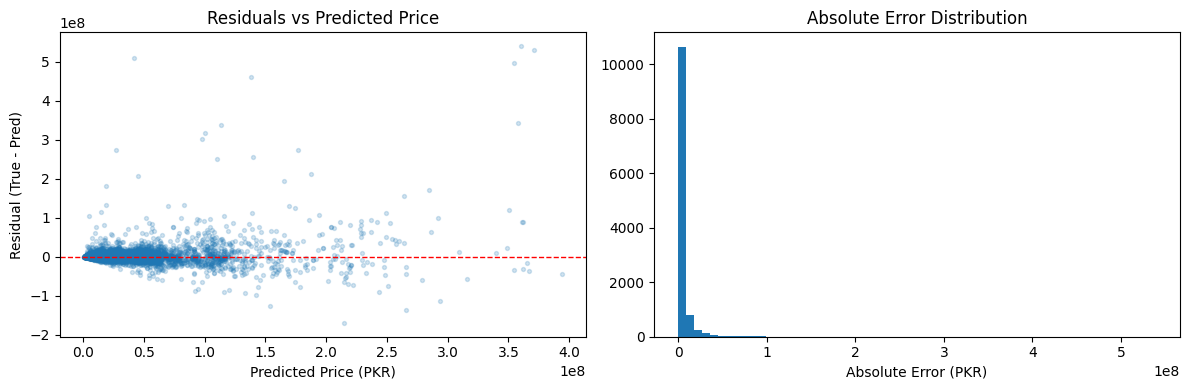

Top 10 cities by highest average absolute error (PKR):


,city,n_samples,mae_city,median_abs_error
0,Islamabad,1687,7161952.46,1836977.61
1,Lahore,4074,4999124.82,1646217.12
2,Karachi,4703,4741661.69,1500747.62
3,Faisalabad,419,4013884.90,1173742.09
4,Rawalpindi,1183,3414742.64,1364417.97


Report summary dictionary:
{'final_model': 'Tuned RandomForest', 'test_rmse': 17359885.332203817, 'test_mae': 5011614.579847042, 'test_r2': 0.8116180017186353, 'test_mape': 888.4708500256187, 'note': 'Metrics are on original PKR scale; model trained on log1p(price).'}


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'best_rf' not in globals():
    raise RuntimeError('Tuned model not found. Run Step 4 first.')

# Final test prediction (log-space -> original scale)
y_test_pred_log = best_rf.predict(X_test_processed)
test_result = evaluate_on_original_scale(y_test.values, y_test_pred_log, 'Tuned RandomForest (Test)')
test_result_df = pd.DataFrame([test_result])
test_result_df[['RMSE', 'MAE', 'MAPE']] = test_result_df[['RMSE', 'MAE', 'MAPE']].round(3)
test_result_df['R2'] = test_result_df['R2'].round(5)

print('Final holdout test performance (original PKR scale):')
display(test_result_df)

# Residual diagnostics in original PKR scale
y_test_true = np.expm1(y_test.values)
y_test_pred = np.expm1(np.clip(y_test_pred_log, y_train.min(), y_train.max()))
residuals = y_test_true - y_test_pred
abs_error = np.abs(residuals)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_test_pred, residuals, alpha=0.2, s=8)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Residuals vs Predicted Price')
axes[0].set_xlabel('Predicted Price (PKR)')
axes[0].set_ylabel('Residual (True - Pred)')

axes[1].hist(abs_error, bins=60)
axes[1].set_title('Absolute Error Distribution')
axes[1].set_xlabel('Absolute Error (PKR)')

plt.tight_layout()
plt.show()

# Segment-level diagnostics by city (if available)
test_diag_df = X_test.copy()
test_diag_df['y_true'] = y_test_true
test_diag_df['y_pred'] = y_test_pred
test_diag_df['abs_error'] = np.abs(test_diag_df['y_true'] - test_diag_df['y_pred'])

if 'city' in test_diag_df.columns:
    city_error_df = (
        test_diag_df.groupby('city', dropna=False)['abs_error']
        .agg(['count', 'mean', 'median'])
        .sort_values('mean', ascending=False)
        .head(10)
        .reset_index()
    )
    city_error_df = city_error_df.rename(columns={'count': 'n_samples', 'mean': 'mae_city', 'median': 'median_abs_error'})
    city_error_df[['mae_city', 'median_abs_error']] = city_error_df[['mae_city', 'median_abs_error']].round(2)
    print('Top 10 cities by highest average absolute error (PKR):')
    display(city_error_df)
else:
    print('City column not found; skipping city-level diagnostics.')

# Report-ready summary text
summary_text = {
    'final_model': 'Tuned RandomForest',
    'test_rmse': float(test_result['RMSE']),
    'test_mae': float(test_result['MAE']),
    'test_r2': float(test_result['R2']),
    'test_mape': float(test_result['MAPE']),
    'note': 'Metrics are on original PKR scale; model trained on log1p(price).',
}
print('Report summary dictionary:')
print(summary_text)

## Step 5 - Final Test Evaluation and Diagnostics
Evaluate the tuned model on untouched test data and generate report-ready diagnostics.

In [10]:
import os
import json
import joblib
import numpy as np

# Robust percentage metrics (MAPE can explode for very small true prices)
y_true = np.expm1(y_test.values)
y_pred = np.expm1(np.clip(y_test_pred_log, y_train.min(), y_train.max()))
abs_err = np.abs(y_true - y_pred)

# Weighted MAPE and SMAPE
wmape = abs_err.sum() / np.maximum(np.abs(y_true).sum(), 1e-12)
smape = np.mean((2.0 * abs_err) / np.maximum(np.abs(y_true) + np.abs(y_pred), 1e-12))

robust_metrics = {
    'RMSE': float(test_result['RMSE']),
    'MAE': float(test_result['MAE']),
    'R2': float(test_result['R2']),
    'WMAPE': float(wmape),
    'SMAPE': float(smape),
}

print('Robust test metrics:')
print(robust_metrics)

# Save artifacts
artifacts_dir = 'artifacts'
os.makedirs(artifacts_dir, exist_ok=True)

pipeline_bundle = {
    'preprocessor': preprocessor,
    'model': best_rf,
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'dropped_high_cardinality': dropped_high_cardinality,
}
joblib.dump(pipeline_bundle, os.path.join(artifacts_dir, 'house_price_pipeline.joblib'))

report_payload = {
    'project': 'Pakistan Housing Price Prediction',
    'target': 'price (PKR)',
    'target_transform': 'log1p',
    'model': 'Tuned RandomForest',
    'best_params': rf_search.best_params_ if 'rf_search' in globals() else None,
    'validation_metrics': model_comparison_df.to_dict(orient='records') if 'model_comparison_df' in globals() else None,
    'test_metrics': robust_metrics,
    'notes': [
        'Training scope: For Sale listings',
        'High-cardinality columns excluded from OHE for memory safety',
        'Use WMAPE/SMAPE for percentage error interpretation',
    ],
}

with open(os.path.join(artifacts_dir, 'final_report.json'), 'w', encoding='utf-8') as f:
    json.dump(report_payload, f, indent=2)

print('Saved:', os.path.join(artifacts_dir, 'house_price_pipeline.joblib'))
print('Saved:', os.path.join(artifacts_dir, 'final_report.json'))

Robust test metrics:
{'RMSE': 17359885.332203817, 'MAE': 5011614.579847042, 'R2': 0.8116180017186353, 'WMAPE': 0.19828822511141778, 'SMAPE': 0.18416011217516903}
Saved: artifacts\house_price_pipeline.joblib
Saved: artifacts\final_report.json


## Step 6 - Robust Metrics, Artifact, and Report File
Finalize with robust percentage metrics, save trained artifacts, and export a machine-readable report summary.

In [11]:
import joblib
import pandas as pd
import numpy as np
from IPython.display import Markdown, display

bundle = joblib.load('artifacts/house_price_pipeline.joblib')
loaded_preprocessor = bundle['preprocessor']
loaded_model = bundle['model']

# Single-row inference sanity check from holdout set
sample_row = X_test.iloc[[0]].copy()
sample_true_price = float(np.expm1(y_test.iloc[0]))

sample_proc = loaded_preprocessor.transform(sample_row)
sample_pred_log = loaded_model.predict(sample_proc)[0]
sample_pred_price = float(np.expm1(np.clip(sample_pred_log, y_train.min(), y_train.max())))

summary_md = f"""
### Final Project Summary
- Objective: Predict housing sale price in PKR for Pakistan listings.
- Final model: Tuned RandomForest.
- Test RMSE: {robust_metrics['RMSE']:,.0f} PKR
- Test MAE: {robust_metrics['MAE']:,.0f} PKR
- Test R2: {robust_metrics['R2']:.4f}
- Test WMAPE: {robust_metrics['WMAPE']:.4f}
- Test SMAPE: {robust_metrics['SMAPE']:.4f}

### Key Findings
- The tuned tree model significantly outperformed linear and naive baselines.
- Error increases on high-price segments, which is expected from heavy-tailed price distributions.
- City-wise diagnostics indicate larger absolute error concentration in major metros due to broader price ranges.

### Inference Sanity Check
- Sample true price: {sample_true_price:,.0f} PKR
- Sample predicted price: {sample_pred_price:,.0f} PKR

### Production Notes
- Saved artifact: artifacts/house_price_pipeline.joblib
- Saved report: artifacts/final_report.json
- Next recommended upgrade: add controlled target encoding for high-cardinality location/agency/agent features.
"""

display(Markdown(summary_md))


### Final Project Summary
- Objective: Predict housing sale price in PKR for Pakistan listings.
- Final model: Tuned RandomForest.
- Test RMSE: 17,359,885 PKR
- Test MAE: 5,011,615 PKR
- Test R2: 0.8116
- Test WMAPE: 0.1983
- Test SMAPE: 0.1842

### Key Findings
- The tuned tree model significantly outperformed linear and naive baselines.
- Error increases on high-price segments, which is expected from heavy-tailed price distributions.
- City-wise diagnostics indicate larger absolute error concentration in major metros due to broader price ranges.

### Inference Sanity Check
- Sample true price: 7,500,000 PKR
- Sample predicted price: 8,851,031 PKR

### Production Notes
- Saved artifact: artifacts/house_price_pipeline.joblib
- Saved report: artifacts/final_report.json
- Next recommended upgrade: add controlled target encoding for high-cardinality location/agency/agent features.


## Step 7 - Executive Summary and Inference Sanity Check
This section generates a concise, stakeholder-ready summary and verifies that the saved model artifact can produce predictions from raw input rows.